<a href="https://colab.research.google.com/github/Yusra-Zafar/LinearRegression-in-PyTorch/blob/main/Linear%20Regression%20PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Code Flow

0. Import libraries
1. Preprocess data
2. Build Linear Regression model
3. Pick a loss function and Optimizer
4. Build a training loop
5. Evaluate model
6. Test on new data point
7. Save model

## 0. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


In [2]:
torch.manual_seed(0)

## 1. Preprocess data

In [3]:
X_train = np.array([
    [3.3], [4.4], [5.5], [6.71], [6.93], [4.168],
    [9.779], [6.182], [7.59], [2.167], [7.042],
    [10.791], [5.313], [7.5997], [3.1]
], dtype=np.float32)

y_train = np.array([
    [1.7], [2.76], [2.09], [3.19], [1.694], [1.573],
    [3.366], [2.596], [2.53], [1.221], [2.827],
    [3.465], [1.65], [2.904], [3.1]
], dtype=np.float32)

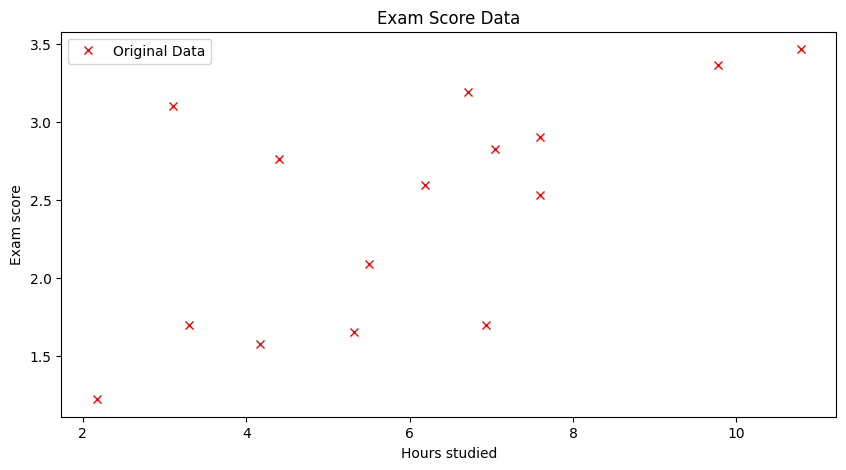

In [4]:
fig = plt.figure(figsize=(10,5))
plt.plot(X_train, y_train, 'rx', label='Original Data')
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.legend()
plt.title("Exam Score Data")
plt.show()

In [5]:
X_train = torch.from_numpy(X_train)
y_train = torch.from_numpy(y_train)

In [6]:
X_train.requires_grad = True
y_train.requires_grad = True

In [7]:
X_train.dtype

torch.float32

## 2. Build Linear Regression Model

In [8]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear = nn.Linear(1,1)

    def forward(self, x):
        out = self.linear(x)

        return out

In [9]:
model = LinearRegression()

In [10]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[-0.0075]])),
             ('linear.bias', tensor([0.5364]))])

## 3. Pick loss function and Optimizer

In [11]:
learning_rate = 0.001
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), learning_rate)

## 4. Build training loop

In [12]:
epochs = 100
epoch_list = []
loss_list = []

for epoch in range(epochs):

    # train model
    model.train()

    # forward pass
    predictions = model(X_train)

    # calculate loss
    loss = criterion(predictions, y_train)

    # back prop
    optimizer.zero_grad()
    loss.backward()

    # update grads
    optimizer.step()

    epoch_list.append(epoch + 1)
    loss_list.append(loss.item())

    print(f"Epoch: {epoch + 1}, Loss: {loss.item():.6f}")


Epoch: 1, Loss: 4.330848
Epoch: 2, Loss: 3.678239
Epoch: 3, Loss: 3.132536
Epoch: 4, Loss: 2.676225
Epoch: 5, Loss: 2.294663
Epoch: 6, Loss: 1.975604
Epoch: 7, Loss: 1.708809
Epoch: 8, Loss: 1.485715
Epoch: 9, Loss: 1.299164
Epoch: 10, Loss: 1.143169
Epoch: 11, Loss: 1.012724
Epoch: 12, Loss: 0.903644
Epoch: 13, Loss: 0.812428
Epoch: 14, Loss: 0.736151
Epoch: 15, Loss: 0.672364
Epoch: 16, Loss: 0.619023
Epoch: 17, Loss: 0.574414
Epoch: 18, Loss: 0.537109
Epoch: 19, Loss: 0.505910
Epoch: 20, Loss: 0.479818
Epoch: 21, Loss: 0.457994
Epoch: 22, Loss: 0.439742
Epoch: 23, Loss: 0.424474
Epoch: 24, Loss: 0.411703
Epoch: 25, Loss: 0.401019
Epoch: 26, Loss: 0.392080
Epoch: 27, Loss: 0.384601
Epoch: 28, Loss: 0.378342
Epoch: 29, Loss: 0.373104
Epoch: 30, Loss: 0.368719
Epoch: 31, Loss: 0.365047
Epoch: 32, Loss: 0.361972
Epoch: 33, Loss: 0.359396
Epoch: 34, Loss: 0.357237
Epoch: 35, Loss: 0.355427
Epoch: 36, Loss: 0.353909
Epoch: 37, Loss: 0.352634
Epoch: 38, Loss: 0.351563
Epoch: 39, Loss: 0.35

### Visualizing loss over epochs

/tmp/ipykernel_8321/1361937577.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


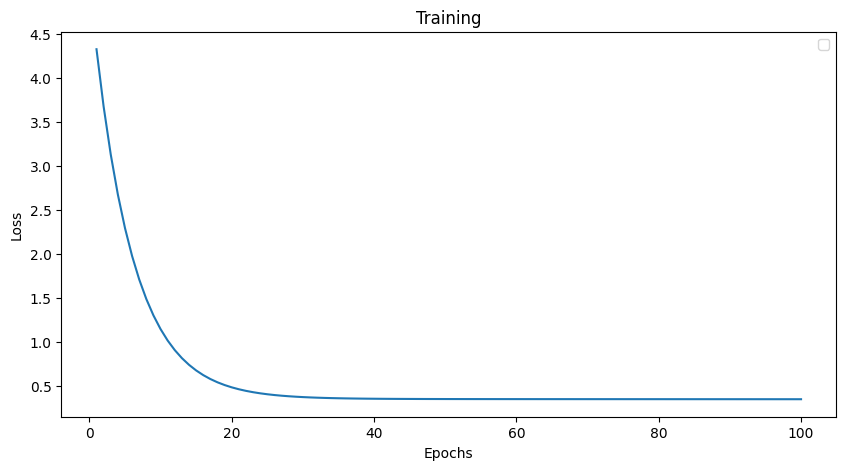

In [13]:
fig=plt.figure(figsize=(10,5))
plt.plot(epoch_list, loss_list,)
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training")
plt.show()

## 5. Evaluate model

### Train data

In [36]:
model.eval()
with torch.no_grad():
    train_pred = model(X_train)
    train_mse = criterion(train_pred, y_train)

print(f"Training MSE: {train_mse.item():.4f}")

Training MSE: 0.3444


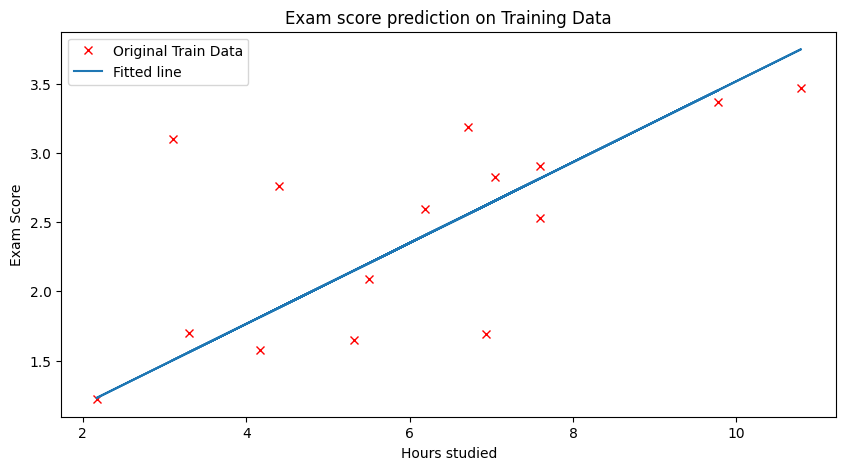

In [30]:
fig = plt.figure(figsize=(10,5))
plt.plot(X_train.detach().numpy(), y_train.detach().numpy(), 'rx', label='Original Train Data')
plt.plot(X_train.detach().numpy(), train_pred.detach().numpy(), label='Fitted line')
plt.xlabel("Hours studied")
plt.ylabel("Exam Score")
plt.legend()
plt.title("Exam score prediction on Training Data")
plt.show()

### Test data

In [23]:
X_test = torch.tensor([[9.4], [3.0], [0.1], [3.6], [4.6], [8.4], [5.3], [1.5], [10.0], [2.9], [9.0], [7.0], [5.2], [4.6], [6.6]], dtype=torch.float32)
y_test = torch.tensor([[3.4], [2.0], [0.3], [2.6], [2.0], [3.8], [3.2], [0.8], [3.9], [2.3], [3.1], [3.0], [3.4], [3.0], [3.5]], dtype=torch.float32)

In [38]:
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    mse_test = criterion(test_pred, y_test)

print(f"Test MSE: {mse_test.item():.4f}")

Test MSE: 0.5185


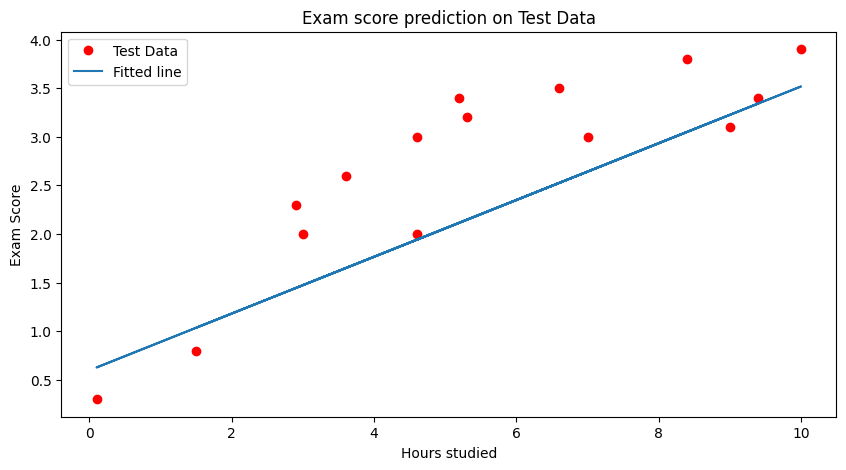

In [39]:
fig=plt.figure(figsize=(10,5))
plt.plot(X_test.detach().numpy(), y_test.detach().numpy(), 'ro', label="Test Data")
plt.plot(X_test.detach().numpy(), test_pred.detach().numpy(), label="Fitted line")
plt.xlabel("Hours studied")
plt.ylabel("Exam Score")
plt.legend()
plt.title("Exam score prediction on Test Data")
plt.show()

## 6. Test on new data point

In [58]:
new_data_point = torch.tensor([[8.0], [2.3], [0.0]], dtype=torch.float32)

In [59]:
model.eval()
with torch.no_grad():
    new_pred = model(new_data_point)

print(f"Prediction on new data point: {new_pred}")

Prediction on new data point: tensor([[2.9331],
        [1.2687],
        [0.5971]])


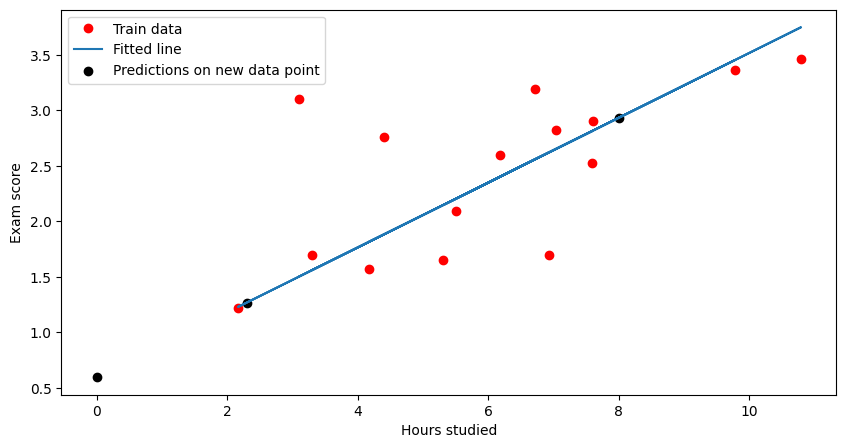

In [60]:
fig = plt.figure(figsize=(10,5))
plt.plot(X_train.detach().numpy(), y_train.detach().numpy(), 'ro', label="Train data" )
plt.plot(X_train.detach().numpy(), train_pred.detach().numpy(), label="Fitted line")
plt.scatter([new_data_point], [new_pred], color='black', label="Predictions on new data point")
plt.legend()
plt.xlabel("Hours studied")
plt.ylabel("Exam score")
plt.show()

## 7. Save model

In [61]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[0.2920]])),
             ('linear.bias', tensor([0.5971]))])

In [62]:
torch.save(model.state_dict(), 'LinearRegressionModel.pth')